<a href="https://colab.research.google.com/github/DerWeiseTeufel/LanguageIdeologies2025/blob/main/EthnoHouseReviewAnalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import pandas as pd
from google.colab import userdata

path = userdata.get('path_review_dag_hotel')
df = pd.read_csv(path)
df.head()

,index,text
0,1,Этнодом в селе Чох Дагестан — это уникальное м...
1,2,"Супер отель, дизайн великолепный, как музей, р..."
2,3,Останавливались здесь в начале сентября 2024 г...
3,4,Нам невероятно крупно повезло забронировали 2 ...
4,5,Интересное место. С историей. Но есть ощущение...


In [ ]:
df_cleaned = df.drop_duplicates(subset=['text'], keep='first')
df_cleaned.shape

(505, 2)

In [ ]:
len("\n".join(df_cleaned.text.tolist())) # 120k symbols, or 20k words

121003

In [ ]:
df = df_cleaned.copy()
df.head()

,index,text
0,1,Этнодом в селе Чох Дагестан — это уникальное м...
1,2,"Супер отель, дизайн великолепный, как музей, р..."
2,3,Останавливались здесь в начале сентября 2024 г...
3,4,Нам невероятно крупно повезло забронировали 2 ...
4,5,Интересное место. С историей. Но есть ощущение...


In [ ]:
!pip install pymorphy3

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


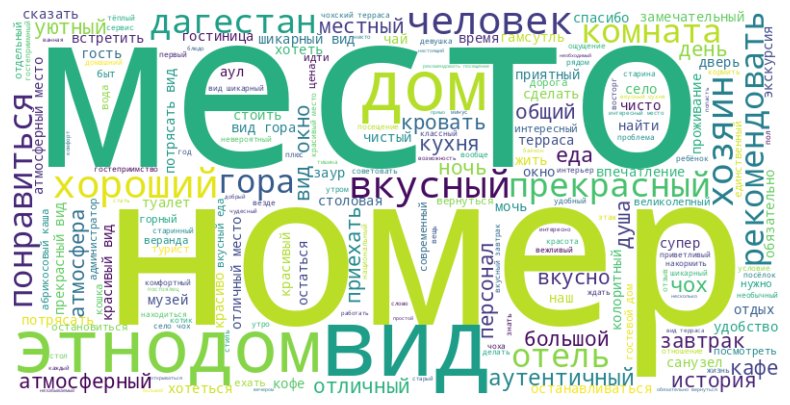

In [ ]:
import pandas as pd
import re
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from nltk.corpus import stopwords
from pymorphy3 import MorphAnalyzer
import nltk

# Download Russian stopwords
nltk.download('stopwords')
ru_stopwords = set(stopwords.words('russian'))
stopwords_additional = "хотя поэтому туда сюда это который просто очень ещё сам такой свой весь очень всё один самый мы вы ты он она они".split()
for stopwrd in stopwords_additional:
  ru_stopwords.add(stopwrd)
def process_text(text):
    # Keep only Russian letters and replace others with space
    cleaned = re.sub(r'[^а-яё]', ' ', text.lower())

    # Tokenize
    tokens = cleaned.split()

    # Remove stopwords


    # Lemmatize using pymorphy2
    morph = MorphAnalyzer()
    lemmas = [morph.parse(t)[0].normal_form for t in tokens]

    lemmas = [t for t in lemmas if t not in ru_stopwords and len(t) > 2]


    return ' '.join(lemmas)

# Apply to DataFrame column
df['processed'] = df['text'].apply(process_text)

# Generate word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(' '.join(df['processed']))

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

Removing these top 3 frequent words: ['вид', 'место', 'номер']


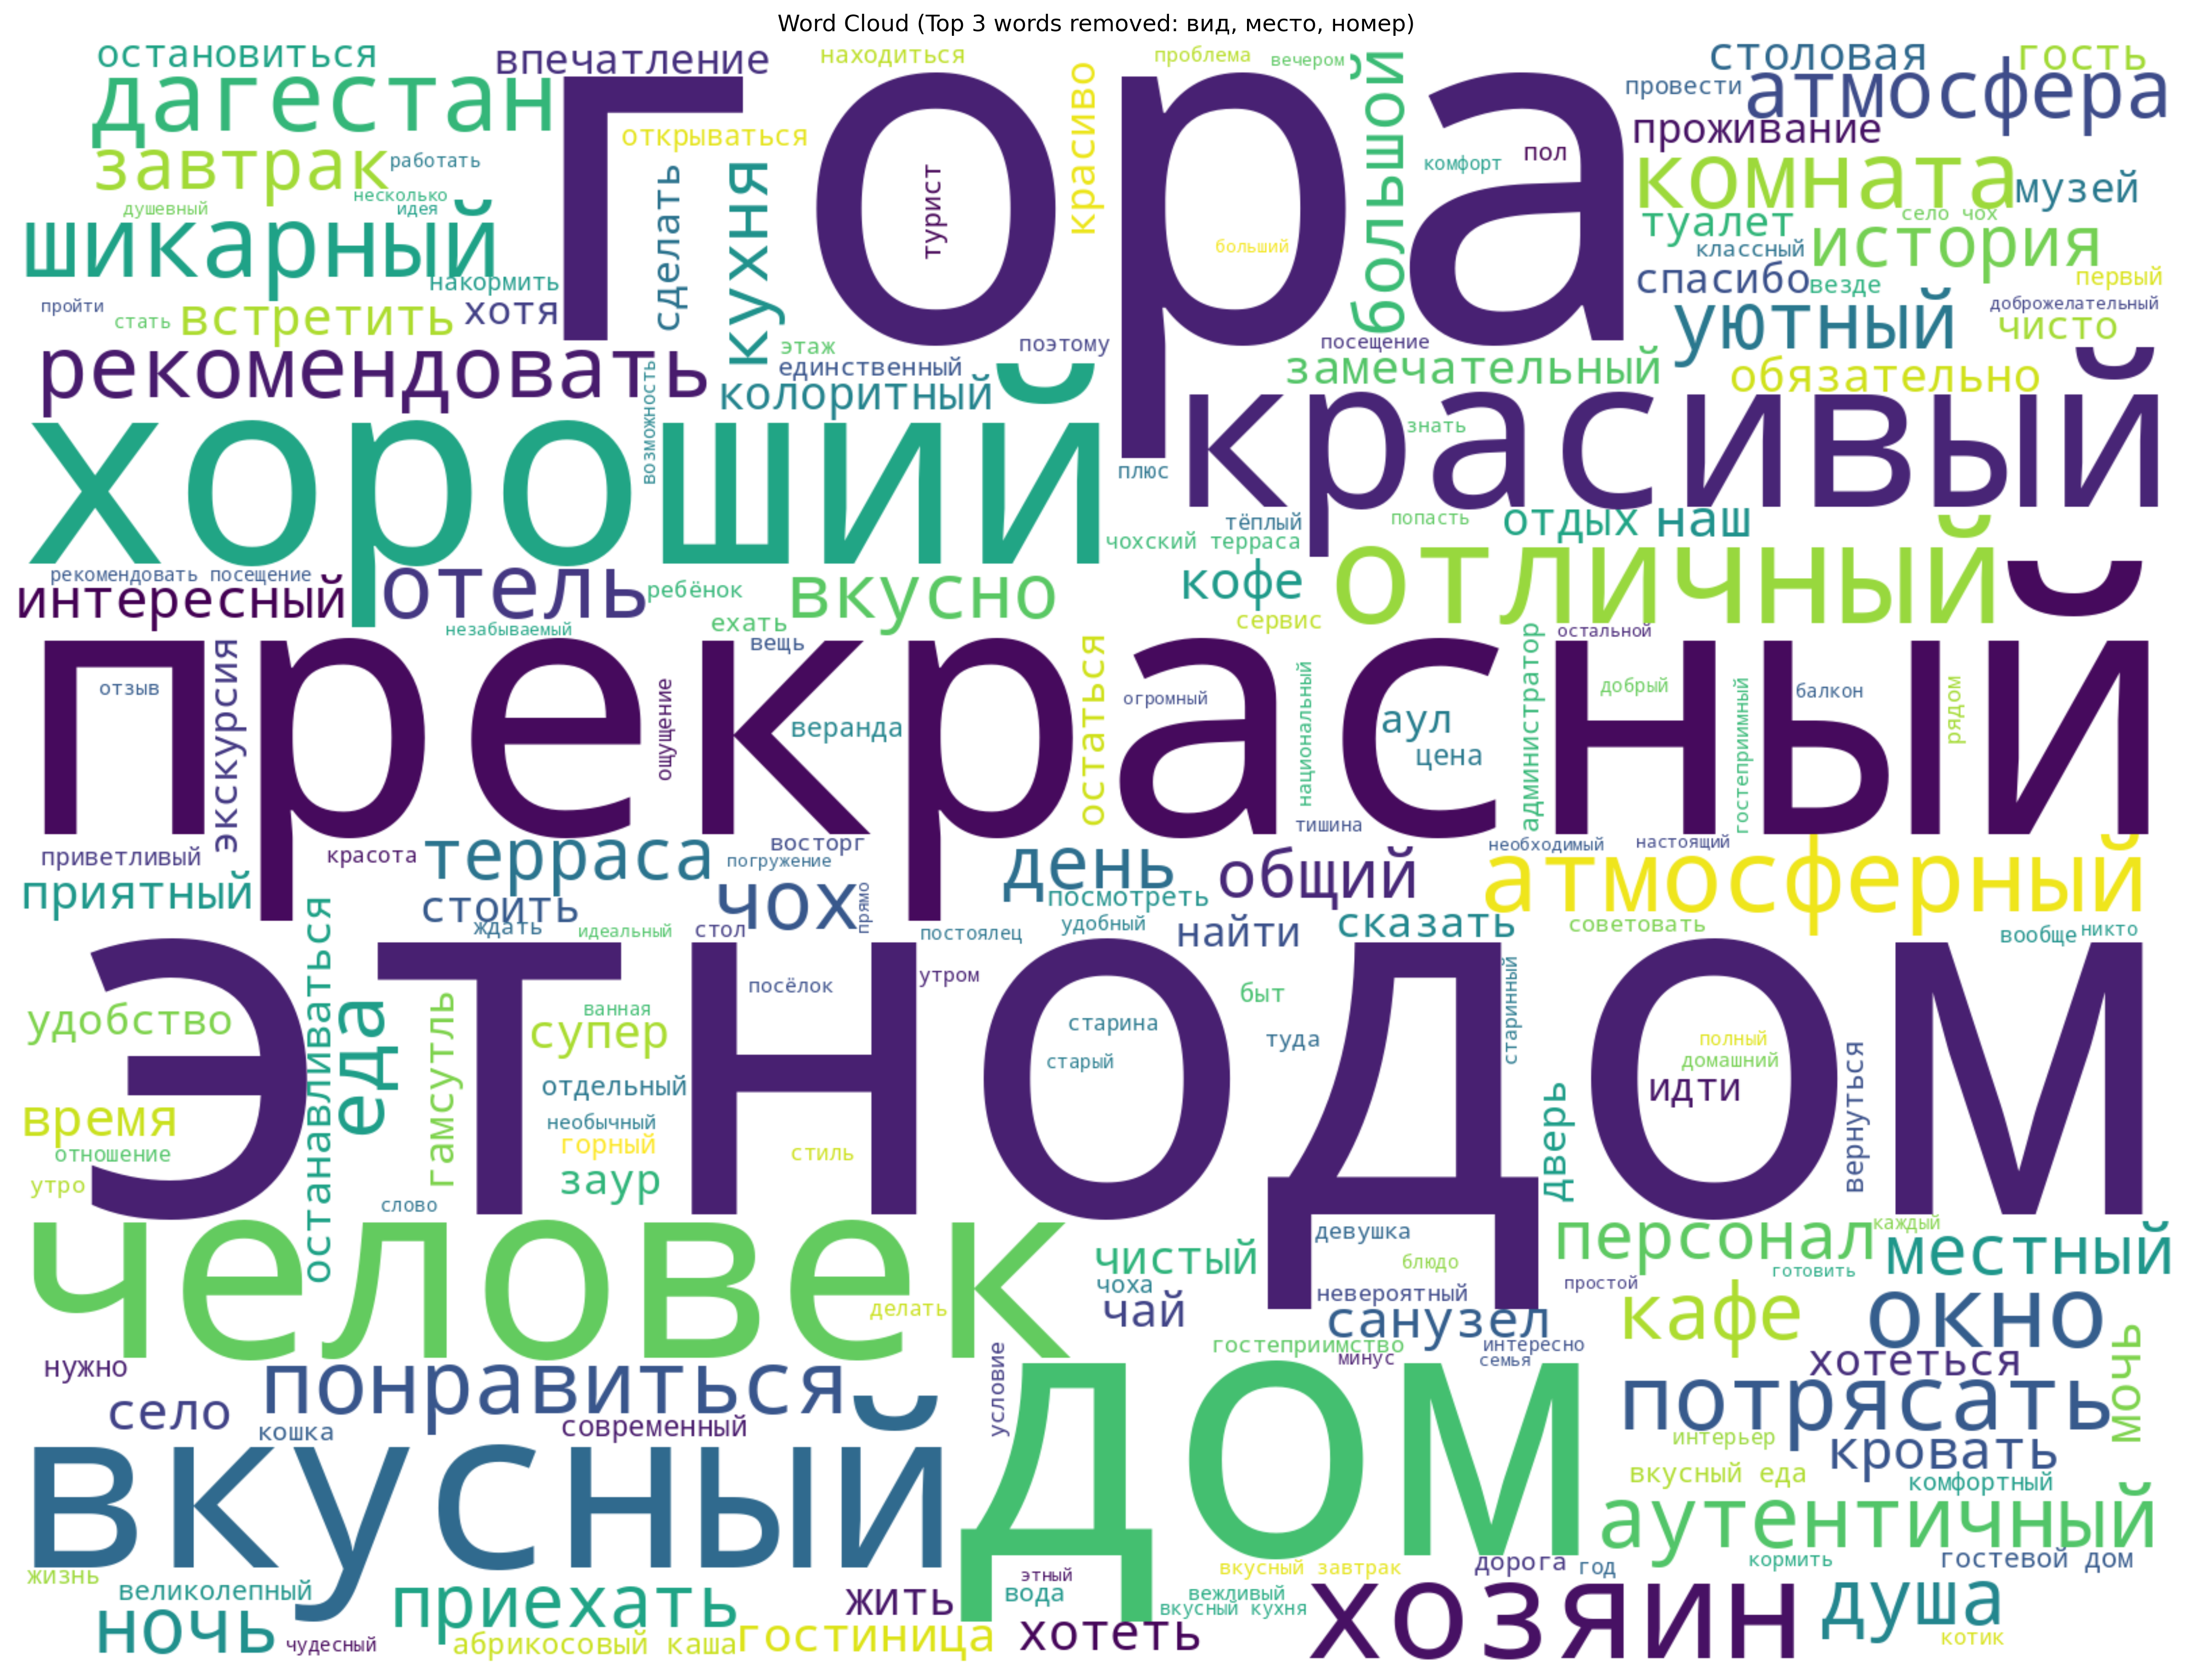

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from collections import Counter

# Combine all processed text
text = " ".join(df['processed'])

# Get word frequencies and find top 3 most frequent words
word_freq = Counter(text.split())
top_3_words = [word for word, freq in word_freq.most_common(3)]

print("Removing these top 3 frequent words:", top_3_words)

# Remove top 3 frequent words
words_list = text.split()
filtered_words = [word for word in words_list if word not in top_3_words]
filtered_text = " ".join(filtered_words)

# Generate high-resolution word cloud
plt.figure(figsize=(16, 12), dpi=300)
wordcloud = WordCloud(
    width=1600,
    height=1200,
    background_color='white',
    max_words=200,
    colormap='viridis',
    random_state=42
).generate(filtered_text)

plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title(f'Word Cloud (Top 3 words removed: {", ".join(top_3_words)})')
plt.tight_layout(pad=0)
plt.savefig('wordcloud_no_top3.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
" ".join(df['processed']).split()

'этнодом село чох дагестан это уникальный место аутентичный горский атмосфера потрясать вид сохраняться традиция старинный дом гость предлагать уютный номер комфорт вкусный местный кухня экскурсия история культура дагестан очень рекомендовать радушие хозяин стильный оформление возможность полный погружение горский жизнь идеальный место знакомство колорит регион супер отель дизайн великолепный музей ресторан дизайнер кухня вкусный вид офигенный персонал дружелюбный номер хороший удовольствие неделя приехать останавливаться начало сентябрь год покорить вид другой отзыв очень понравиться атмосферный аутентичный ребёнок недоумевать почему отель кондиционер телевизор деться люстра потолок весь неравнодушный вид рекомендовать мы невероятно крупно повезти забронировать номер ночь дек январь номер стоить завтрак двое номер прогреть очень тепло это отель достаточно чисто аккуратно бельё белый чистый номер ничто пахнуть хозяйка каждый утро кормить вкусный завтрак абрикосовый каша урбетать просто

In [ ]:
import plotly.express as px
import pandas as pd
from collections import Counter

# Calculate word frequencies
word_freq = Counter(" ".join(df['processed']).split()).most_common(33)

# Create DataFrame
freq_df = pd.DataFrame(word_freq[3:], columns=['word', 'frequency'])

# Create interactive bar chart
fig = px.bar(freq_df,
             x='frequency',
             y='word',
             orientation='h',
             title='30 самых частотных слов в отзывах',
             labels={'frequency': 'Частота', 'word': 'Слова'},
             color='frequency',
             color_continuous_scale='viridis')

# Customize layout
fig.update_layout(
    yaxis={'categoryorder': 'total ascending'},
    height=600,
    showlegend=False,
    font=dict(size=12)
)

# Show plot
fig.show()

Вывод: пользователи ценят Природу (красивый вид, гора ), еду(кухня вкусный завтрак), гостеприимство (хозяин) и конструируют аутентичность (атмосферный)

Добавить в стопслова: это который просто очень

In [ ]:
def advanced_cooccurrence_analysis(df, target_word, level='sentence', top_n=15):
    """
    Advanced co-occurrence analysis with additional metrics
    """
    cooccurrence_counts = Counter()
    total_docs_with_target = 0
    word_doc_freq = Counter()

    target_word = target_word.lower()

    for text in df['processed']:
        if level == 'sentence':
            segments = text.replace('!', '.').replace('?', '.').split('.')
        else:
            segments = [text]

        for segment in segments:
            words = segment.strip().split()
            if target_word in words:
                total_docs_with_target += 1
                unique_words = set(words)
                for word in unique_words:
                    if word != target_word and len(word) > 2:
                        word_doc_freq[word] += 1
                        cooccurrence_counts[word] += words.count(word)

    # Calculate co-occurrence strength (PMI-like metric)
    results = []
    total_docs = len(df)

    for word, cooccur_count in cooccurrence_counts.most_common(top_n * 2):
        if word_doc_freq[word] > 1:  # Filter very rare co-occurrences
            # Simple association strength
            association_strength = cooccur_count / total_docs_with_target
            results.append((word, cooccur_count, association_strength))

    # Sort by co-occurrence count and take top_n
    results.sort(key=lambda x: x[1], reverse=True)
    return results[:top_n]

# Visualization with strength indicator
target_word = "аутентичный"  # staff
advanced_results = advanced_cooccurrence_analysis(df, target_word, level='sentence')

# Create enhanced visualization
adv_df = pd.DataFrame(advanced_results, columns=['word', 'cooccurrence_count', 'association_strength'])

fig = px.bar(adv_df,
             x='cooccurrence_count',
             y='word',
             orientation='h',
             title=f'Top Co-occurring Words with "{target_word}"<br><sub>Size indicates association strength</sub>',
             labels={'cooccurrence_count': 'Co-occurrence Frequency'},
             color='association_strength',
             color_continuous_scale='reds',
             hover_data=['association_strength'])

fig.update_layout(yaxis={'categoryorder': 'total ascending'}, height=500)
fig.show()

In [ ]:
advanced_cooccurrence_analysis(df, 'аутентичный')

[('номер', 34, 0.723404255319149),
 ('место', 33, 0.7021276595744681),
 ('вид', 30, 0.6382978723404256),
 ('дом', 15, 0.3191489361702128),
 ('этнодом', 14, 0.2978723404255319),
 ('завтрак', 14, 0.2978723404255319),
 ('хороший', 12, 0.2553191489361702),
 ('хозяин', 11, 0.23404255319148937),
 ('рекомендовать', 11, 0.23404255319148937),
 ('душа', 10, 0.2127659574468085),
 ('дагестан', 9, 0.19148936170212766),
 ('человек', 9, 0.19148936170212766),
 ('прекрасный', 9, 0.19148936170212766),
 ('атмосфера', 8, 0.1702127659574468),
 ('понравиться', 8, 0.1702127659574468)]

In [ ]:
advanced_cooccurrence_analysis(df, 'атмосферный')

[('место', 51, 0.8225806451612904),
 ('вид', 33, 0.532258064516129),
 ('номер', 24, 0.3870967741935484),
 ('вкусный', 21, 0.3387096774193548),
 ('дом', 12, 0.1935483870967742),
 ('шикарный', 12, 0.1935483870967742),
 ('гора', 12, 0.1935483870967742),
 ('уютный', 11, 0.1774193548387097),
 ('хозяин', 11, 0.1774193548387097),
 ('окно', 11, 0.1774193548387097),
 ('этнодом', 10, 0.16129032258064516),
 ('потрясать', 10, 0.16129032258064516),
 ('еда', 9, 0.14516129032258066),
 ('рекомендовать', 8, 0.12903225806451613),
 ('завтрак', 8, 0.12903225806451613)]

In [ ]:
advanced_cooccurrence_analysis(df, 'чох')

[('место', 46, 0.7540983606557377),
 ('номер', 36, 0.5901639344262295),
 ('этнодом', 36, 0.5901639344262295),
 ('вид', 28, 0.45901639344262296),
 ('дом', 26, 0.4262295081967213),
 ('село', 22, 0.36065573770491804),
 ('гора', 18, 0.29508196721311475),
 ('человек', 15, 0.2459016393442623),
 ('хозяин', 14, 0.22950819672131148),
 ('аул', 14, 0.22950819672131148),
 ('дагестан', 12, 0.19672131147540983),
 ('рекомендовать', 12, 0.19672131147540983),
 ('хороший', 12, 0.19672131147540983),
 ('комната', 12, 0.19672131147540983),
 ('вкусный', 11, 0.18032786885245902)]